In [9]:
import gc
import os
from pathlib import Path
import random
import sys

from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings(action='ignore')

import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from datetime import timedelta
from IPython.core.display import display, HTML

# --- plotly ---
from plotly import tools, subplots
import plotly.offline as py
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.express as px
import plotly.figure_factory as ff
import plotly.io as pio
pio.templates.default = "plotly_dark"

# --- models ---
from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.utils import shuffle
from scipy import integrate, optimize
from sklearn.metrics import mean_squared_log_error

import tensorflow.compat.v1 as tf 
from tensorflow.compat.v1.keras import layers
from tensorflow.compat.v1.keras import Input
from tensorflow.compat.v1.keras.models import Model
from tensorflow.compat.v1.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.compat.v1.keras.layers import LSTM, Dense, Dropout, Concatenate, Embedding, Reshape, Flatten, Conv1D, Conv2D, MaxPooling1D, AveragePooling1D, BatchNormalization

# --- setup ---
#pd.set_option('max_columns', 50)
from aux_sir_funcs import *


import os
os.environ['CUDA_VISIBLE_DEVICES'] = '3'
config = tf.ConfigProto()

config.gpu_options.allow_growth = True
session = tf.Session(config=config)

# to account for updates when files change
%load_ext autoreload
%autoreload 2

In [47]:
from gan_funcs import *

In [48]:
from aux_sir_funcs import *

In [36]:
russia_df['r_population'][0]

145922010.0

(1102, 19)
lstm
145922010.0


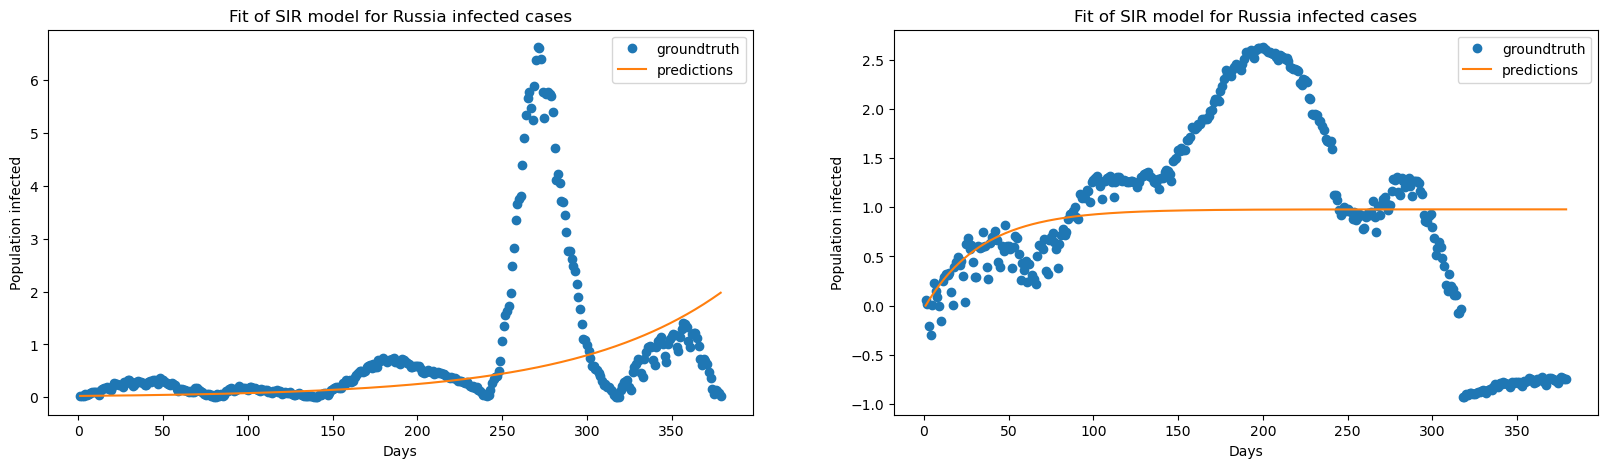

Optimal parameters: beta = 1.1321498529430636  and gamma =  1.1618017037631672


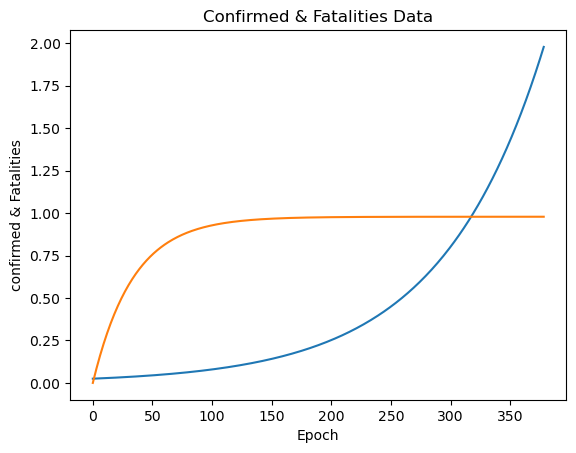

after lstm (None, 50, 64)
fin (None, 50, 1)
(None, 50, 1)
network build success
Iter: 0      d_loss: 1.382       g_loss: 0.6927
Iter: 1      d_loss: 1.381       g_loss: 0.6923


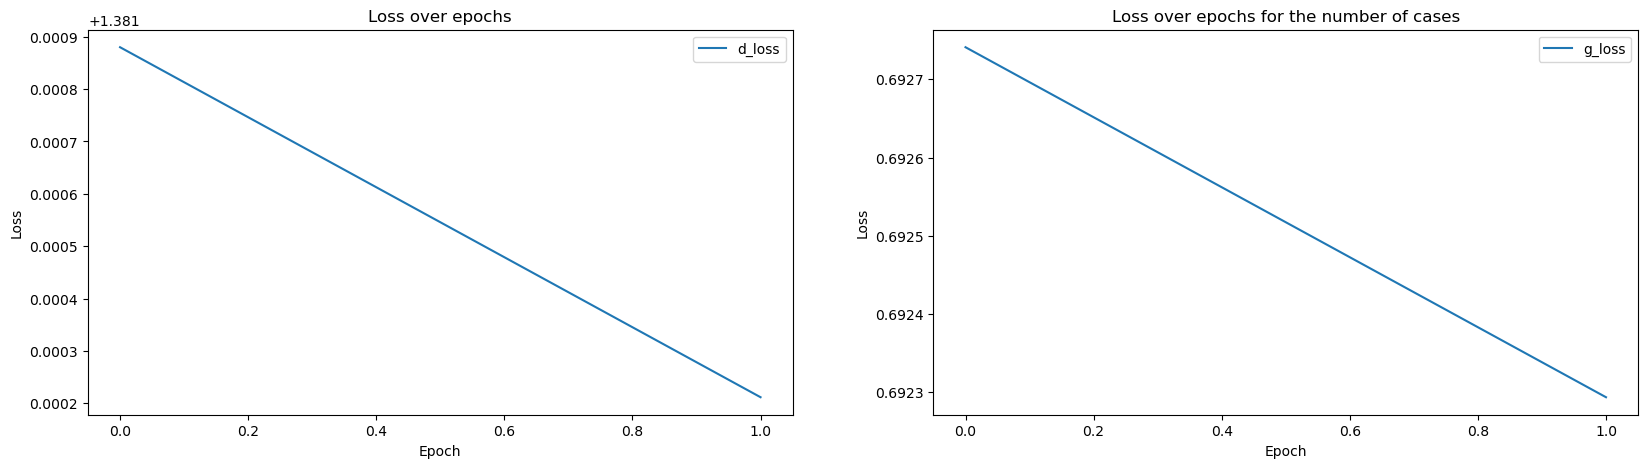

CPU times: total: 1min 5s
Wall time: 7.87 s


In [49]:
%%time
## noiseSet = True  数据AN
## noiseSet = False 随机噪声数据
gan2 = ganData(50, 50, russia_df.copy(), 
              "Russia", noiseSet = True, 
              colName = "confirmed_trend", iter_epoch=2,
              gan_t = 'lstm') #confirmed_trend   fatality_trend


(1102, 19)

145922010.0


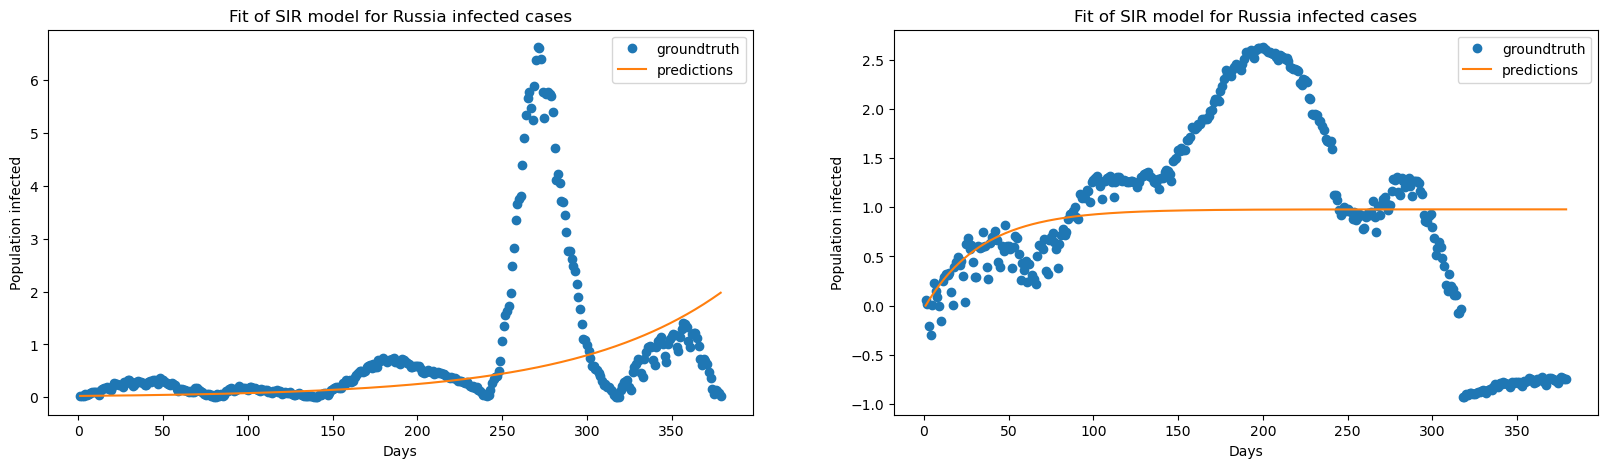

Optimal parameters: beta = 1.1321498529430636  and gamma =  1.1618017037631672


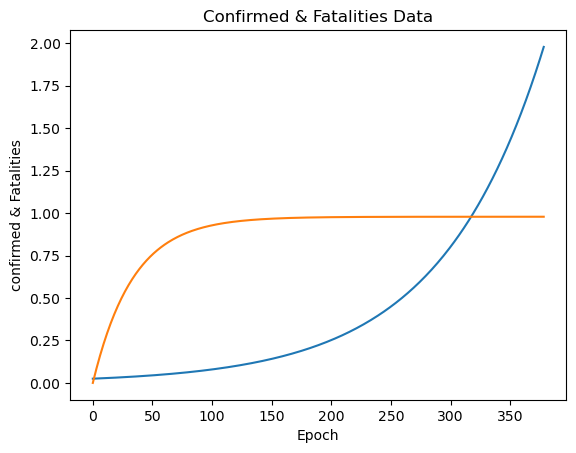

(None, 50, 1, 1)
network build success
Iter: 0      d_loss: 1.393       g_loss: 0.693
Iter: 1      d_loss: 1.391       g_loss: 0.693


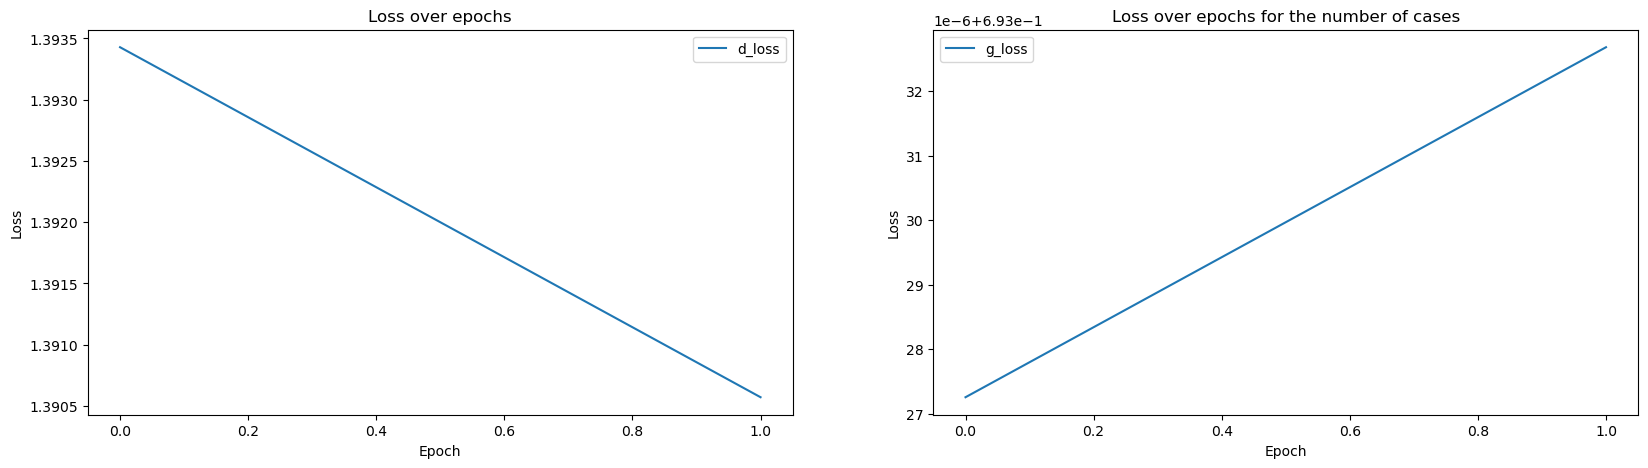

CPU times: total: 1min 16s
Wall time: 7.73 s


In [50]:
%%time
## noiseSet = True  数据AN
## noiseSet = False 随机噪声数据
gan2 = ganData(50, 50, russia_df.copy(), 
              "Russia", noiseSet = True, 
              colName = "confirmed_trend", iter_epoch=2,
              gan_t = '') #confirmed_trend   fatality_trend


In [5]:
all_df = pd.read_csv("data/owid-covid-data-old.csv",  keep_default_na=False)
population_ =pd.read_csv('data/population_by_country_2020.xls', sep=',')

In [6]:
population_.loc[population_['Country (or dependency)'] == 'United States', 'Country (or dependency)'] = "US"
population_.loc[population_['Country (or dependency)'] == 'South Korea', 'Country (or dependency)'] = "Korea, South"
population_.loc[population_['Country (or dependency)'] == 'Sao Tome & Principe', 'Country (or dependency)'] = "Sao Tome and Principe"
population_.loc[population_['Country (or dependency)'] == 'Taiwan', 'Country (or dependency)'] = "Taiwan*"

population_.loc[population_['Country (or dependency)'] == 'Myanmar', 'Country (or dependency)'] = "Burma"
population_.loc[population_['Country (or dependency)'] == 'Congo', 'Country (or dependency)'] = "Congo (Brazzaville)"
population_.loc[population_['Country (or dependency)'] == 'DR Congo', 'Country (or dependency)'] = "Congo (Kinshasa)"
population_.loc[population_['Country (or dependency)'] == "Côte d'Ivoire", 'Country (or dependency)'] = "Cote d'Ivoire"

population_.loc[population_['Country (or dependency)'] == 'Czech Republic (Czechia)', 'Country (or dependency)'] = "Czechia"
population_.loc[population_['Country (or dependency)'] == 'Saint Kitts & Nevis', 'Country (or dependency)'] = "Saint Kitts and Nevis"
population_.loc[population_['Country (or dependency)'] == 'St. Vincent & Grenadines', 'Country (or dependency)'] = "Saint Vincent and the Grenadines"


population_.rename({'Population (2020)': 'population', 'Country (or dependency)': 'country', 'Yearly Change': 'yearly_change', 
                 'Net Change': 'net_change', 'Density (P/Km²)': 'density', 'Land Area (Km²)': 'land_area', 
                 'Migrants (net)': 'migrants', 'Fert. Rate': 'rert_rate', 'Med. Age': 'med_age', 
                 'Urban Pop %': 'urban_pop', 'World Share': 'world_share'}, axis=1, inplace=True)
population_["yearly_change"] = population_["yearly_change"].apply(lambda x: x.replace(" ", "").replace("%","")).astype("float")
population_["urban_pop"] = population_["urban_pop"].apply(lambda x: x.replace(" ", "").replace("N.A.","0").replace("%","")).astype("float")
population_["world_share"] = population_["world_share"].apply(lambda x: x.replace(" ", "").replace("%","")).astype("float")

population_["rert_rate"] = population_["rert_rate"].apply(lambda x: x.replace("N.A.", "0.0")).astype("float")
population_["med_age"] = population_["med_age"].apply(lambda x: x.replace("N.A.", "0.0")).astype("float")

population_.rert_rate.fillna(0, inplace=True)
population_.migrants.fillna(0, inplace=True)

population_["net_change"] = population_["net_change"].astype("float")
population_["density"] = population_["density"].astype("float")
population_["land_area"] = population_["land_area"].astype("float")
population_["population"] = population_["population"].astype("float")

population_["r_population"] = population_["population"]

population_["population"] = population_["population"] / max(population_["population"])
population_["yearly_change"] = population_["yearly_change"] / max(population_["yearly_change"])
population_["urban_pop"] = population_["urban_pop"] / max(population_["urban_pop"])
population_["world_share"] = population_["world_share"] / max(population_["world_share"])
population_["net_change"] = population_["net_change"] / max(population_["net_change"])
population_["density"] = population_["density"] / max(population_["density"])
population_["land_area"] = population_["land_area"] / max(population_["land_area"])
population_["rert_rate"] = population_["rert_rate"] / max(population_["rert_rate"])
population_["med_age"] = population_["med_age"] / max(population_["med_age"])
population_["migrants"] = population_["migrants"] / max(population_["migrants"])

In [7]:
global_df = deal_global_df(population_, all_df, "World", "global")         ####
us_df     = deal_country_data(population_, all_df, "United States", "US")  ####
italy_df  = deal_country_data(population_, all_df, "Italy", "Italy")    ####
france_df = deal_country_data(population_, all_df, "France", "France")  ####
japan_df  = deal_country_data(population_, all_df, "Japan", "Japan")    ####

china_df   = deal_country_data(population_, all_df, "China", "China")
spain_df   = deal_country_data(population_, all_df, "Spain", "Spain")
uk_df      = deal_country_data(population_, all_df, "United Kingdom", "United Kingdom")
germany_df = deal_country_data(population_, all_df, "Germany", "Germany")

koread_df = deal_country_data(population_, all_df, "South Korea", "South Korea")

canada_df = deal_country_data(population_, all_df, "Canada", "Canada")
india_df = deal_country_data(population_, all_df, "India", "India")
russia_df = deal_country_data(population_, all_df, "Russia", "Russia")

In [13]:
global_df_ = addCsvDelNa(global_df)
us_df_     = addCsvDelNa(us_df)

# italy_df_  = addCsvDelNa(italy_df)
# france_df_ = addCsvDelNa(france_df)
# japan_df_  = addCsvDelNa(japan_df)

italy_df_  = addCsvRepNa(italy_df)
france_df_ = addCsvRepNa(france_df)
japan_df_  = addCsvRepNa(japan_df)

china_df_   = addCsvRepNa(china_df)
spain_df_   = addCsvRepNa(spain_df)
uk_df_      = addCsvDelNa(uk_df)
germany_df_ = addCsvDelNa(germany_df)


koread_df_ = addCsvRepNa(koread_df)

# china_df_   = addCsvDelNa(china_df)
# spain_df_   = addCsvDelNa(spain_df)
# uk_df_      = addCsvDelNa(uk_df)
# germany_df_ = addCsvDelNa(germany_df)

In [14]:
canada_df_ = addCsvDelNa(canada_df)
india_df_  = addCsvDelNa(india_df)
russia_df_ = addCsvDelNa(russia_df)

### SIR

60479424.0


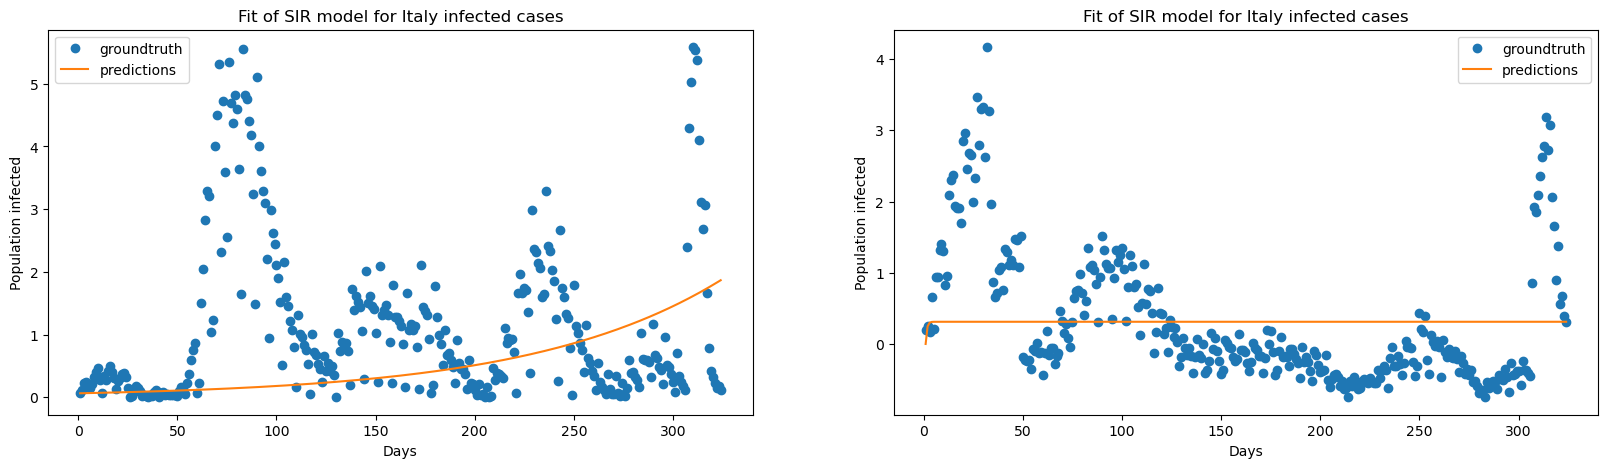

Optimal parameters: beta = 6.1352056154511265  and gamma =  7.722796271096148


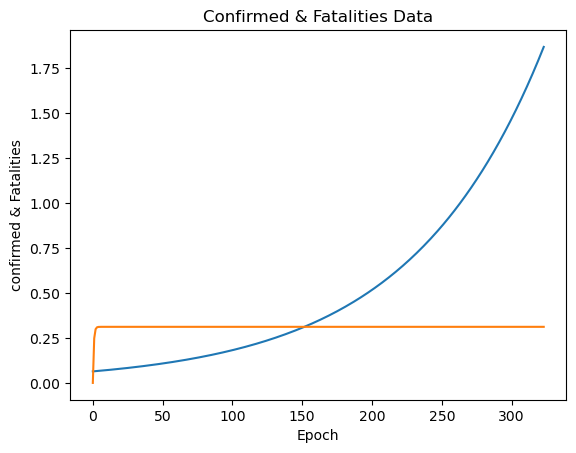

,confirmed,fatalities,date,day
0,0.064065,0.000000,2020-01-31,0
1,0.064737,0.247937,2020-02-01,1
2,0.065417,0.298620,2020-02-02,2
3,0.066103,0.308980,2020-02-03,3
4,0.066797,0.311098,2020-02-04,4
...,...,...,...,...
319,1.790386,0.311642,2020-12-15,319
320,1.809172,0.311642,2020-12-16,320
321,1.828154,0.311642,2020-12-17,321
322,1.847336,0.311642,2020-12-18,322


In [21]:
deal_SIR(italy_df, "Italy", population_)

330610570.0


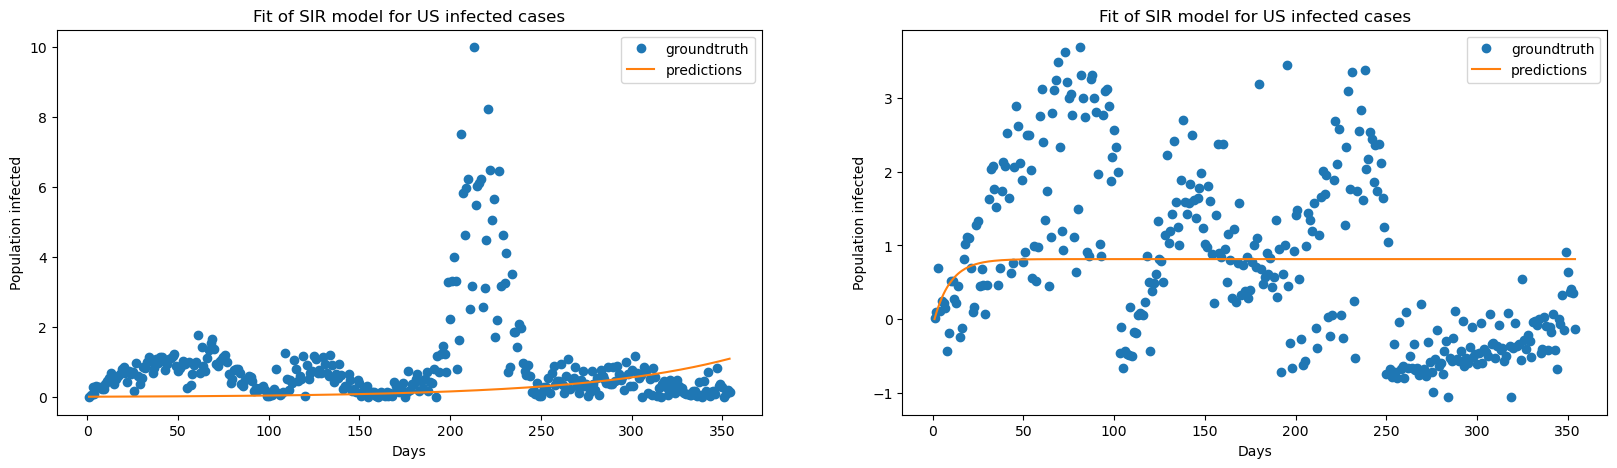

Optimal parameters: beta = 6.067190116431254  and gamma =  6.175704608538267


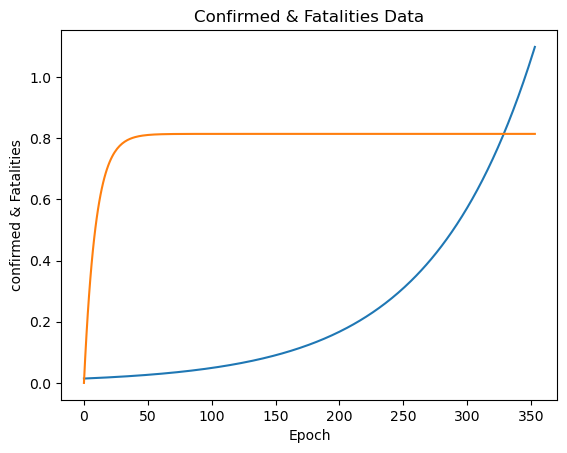

,confirmed,fatalities,date,day
0,0.014306,0.000000,2020-01-22,0
1,0.014483,0.083728,2020-01-23,1
2,0.014663,0.158845,2020-01-24,2
3,0.014844,0.226238,2020-01-25,3
4,0.015028,0.286701,2020-01-26,4
...,...,...,...,...
349,1.045776,0.814200,2021-01-05,349
350,1.058716,0.814200,2021-01-06,350
351,1.071815,0.814200,2021-01-07,351
352,1.085077,0.814200,2021-01-08,352


In [22]:
deal_SIR(us_df, "US", population_)

7777967034.0


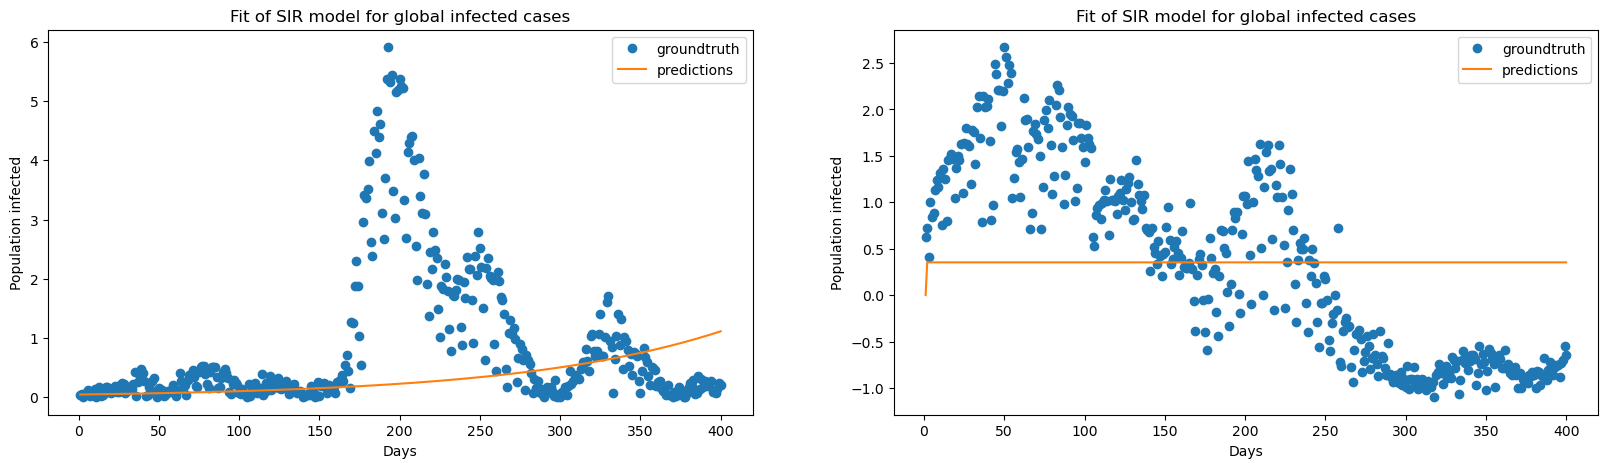

Optimal parameters: beta = 72.20211256828316  and gamma =  83.49387774324103


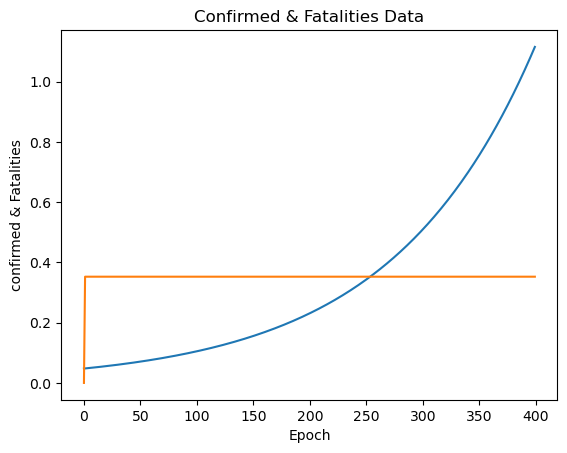

,confirmed,fatalities,date,day
0,0.047671,0.000000,2020-01-22,0
1,0.048049,0.352488,2020-01-23,1
2,0.048431,0.352492,2020-01-24,2
3,0.048815,0.352492,2020-01-25,3
4,0.049202,0.352492,2020-01-26,4
...,...,...,...,...
395,1.080293,0.352492,2021-02-20,395
396,1.088861,0.352492,2021-02-21,396
397,1.097498,0.352492,2021-02-22,397
398,1.106203,0.352492,2021-02-23,398


In [23]:
deal_SIR(global_df, "global", population_)

### GAN

In [13]:
tf.compat.v1.disable_eager_execution()

(1102, 19)
145922010.0


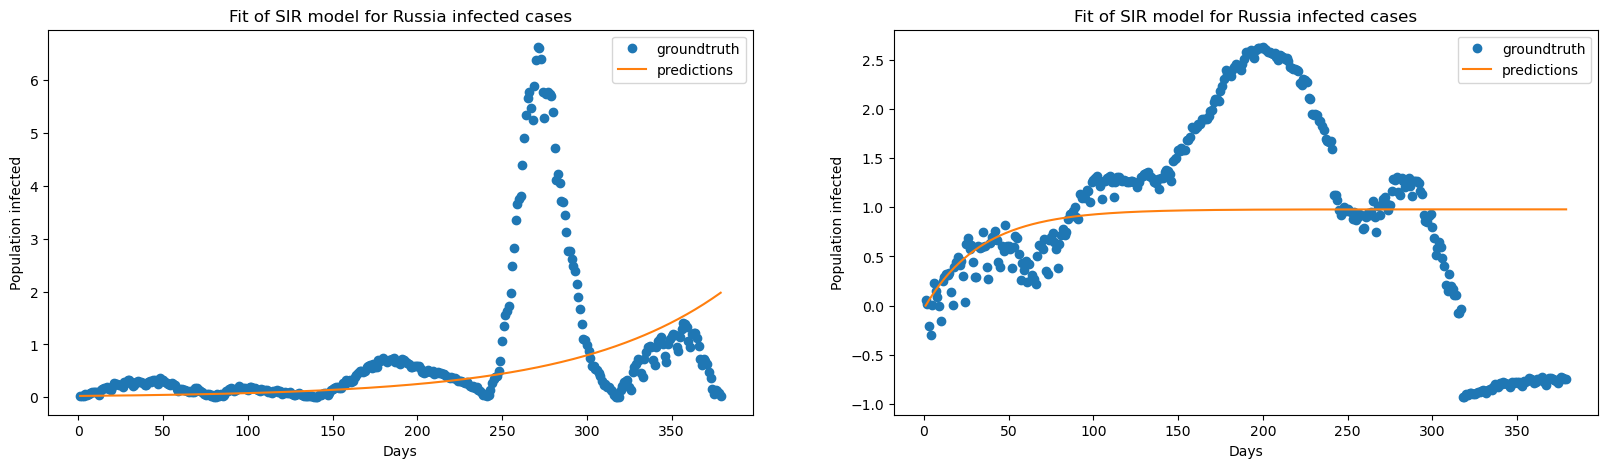

Optimal parameters: beta = 1.1321498529430636  and gamma =  1.1618017037631672


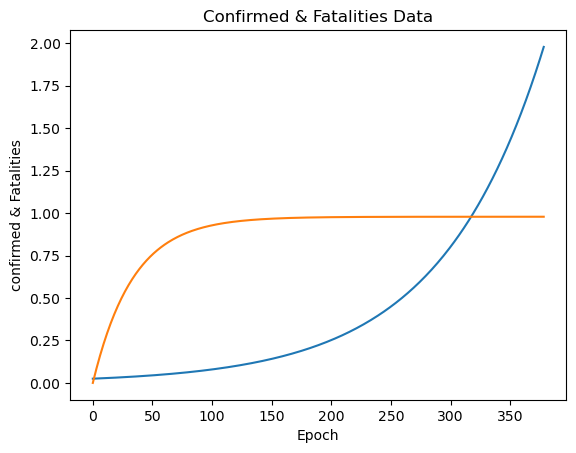

(None, 50, 1024)
after lstm (None, 50, 64)


C:\Users\105\AppData\Local\Temp\ipykernel_1892\2780617686.py:77: UserWarning:

`tf.layers.dense` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Dense` instead.

C:\Users\105\AppData\Local\Temp\ipykernel_1892\2780617686.py:87: UserWarning:

`tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.

C:\Users\105\AppData\Local\Temp\ipykernel_1892\2780617686.py:127: UserWarning:

`tf.layers.dense` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Dense` instead.

C:\Users\105\AppData\Local\Temp\ipykernel_1892\2780617686.py:53: UserWarning:

`tf.layers.dense` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Dense` instead.

C:\Users\105\AppData\Local\Temp\ipykernel_1892\2780617686.py:56: UserWarning:

`tf.layers.dense` is deprecated and will be removed in a future 

after lstm + dense (None, 50, 1)
fin (None, 50, 1)
(None, 50, 1)
network build success
Iter: 0      d_loss: 1.377       g_loss: 0.6927
Iter: 1      d_loss: 1.376       g_loss: 0.6923
Iter: 2      d_loss: 1.375       g_loss: 0.6918
Iter: 3      d_loss: 1.374       g_loss: 0.6913
Iter: 4      d_loss: 1.373       g_loss: 0.6907


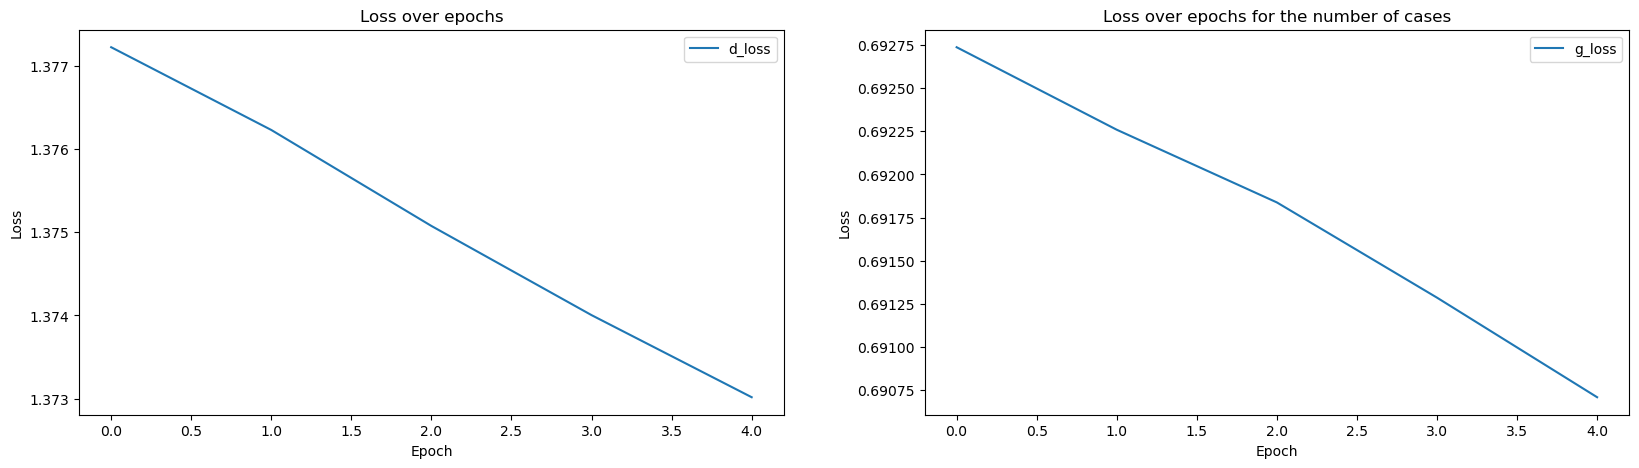

CPU times: total: 2min 28s
Wall time: 16.4 s


In [38]:
%%time
## noiseSet = True  数据AN
## noiseSet = False 随机噪声数据
gan2 = ganData(50, 50, russia_df.copy(), 
              "Russia", noiseSet = True, 
              colName = "confirmed_trend", iter_epoch=5) #confirmed_trend   fatality_trend


In [18]:
gdata2 = gan2.predict(1000)
np.save('ganDataNew/2stand_russia_del30_confirmed_noise_1000',gdata2 )  #confirmed  fatality
gdata2.shape

INFO:tensorflow:Restoring parameters from ./gan_model/Russia_model


(1000, 61, 1)

(1102, 19)
145922010.0


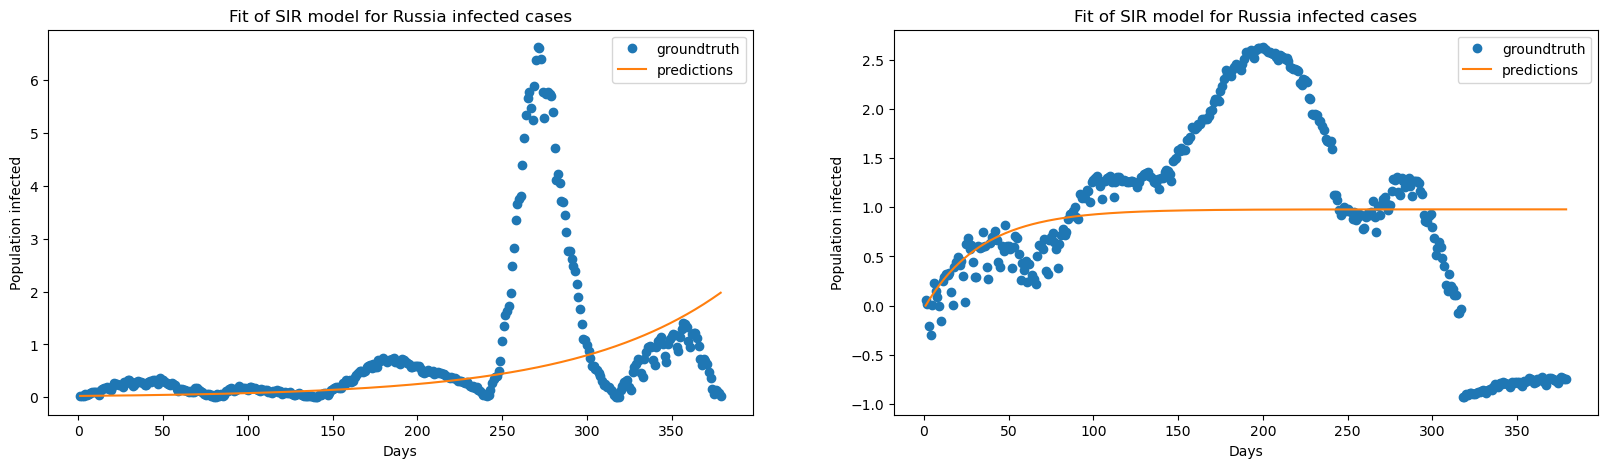

Optimal parameters: beta = 1.1321498529430636  and gamma =  1.1618017037631672


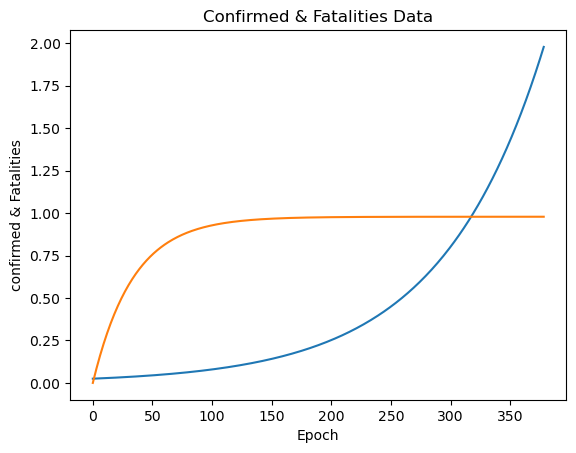

(None, 61, 1, 1)


C:\Users\105\AppData\Local\Temp\ipykernel_26112\1756920443.py:75: UserWarning:

`tf.layers.dense` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Dense` instead.

C:\Users\105\AppData\Local\Temp\ipykernel_26112\1756920443.py:82: UserWarning:

`tf.layers.conv2d_transpose` is deprecated and will be removed in a future version. Please Use `tf.keras.layers.Conv2DTranspose` instead.

C:\Users\105\AppData\Local\Temp\ipykernel_26112\1756920443.py:88: UserWarning:

`tf.layers.conv2d_transpose` is deprecated and will be removed in a future version. Please Use `tf.keras.layers.Conv2DTranspose` instead.

C:\Users\105\AppData\Local\Temp\ipykernel_26112\1756920443.py:94: UserWarning:

`tf.layers.conv2d_transpose` is deprecated and will be removed in a future version. Please Use `tf.keras.layers.Conv2DTranspose` instead.

C:\Users\105\AppData\Local\Temp\ipykernel_26112\1756920443.py:100: UserWarning:

`tf.layers.conv2d_transpose` is deprecated and will be removed i

network build success
Iter: 0      d_loss: 1.366       g_loss: 0.6921
Iter: 1      d_loss: 1.363       g_loss: 0.6912
Iter: 2      d_loss: 1.361       g_loss: 0.6902
Iter: 3      d_loss: 1.36       g_loss: 0.689
Iter: 4      d_loss: 1.358       g_loss: 0.6877
Iter: 5      d_loss: 1.356       g_loss: 0.6861
Iter: 6      d_loss: 1.355       g_loss: 0.6844
Iter: 7      d_loss: 1.354       g_loss: 0.6824
Iter: 8      d_loss: 1.353       g_loss: 0.6802
Iter: 9      d_loss: 1.352       g_loss: 0.6778
Iter: 10      d_loss: 1.351       g_loss: 0.6752
Iter: 11      d_loss: 1.351       g_loss: 0.6723
Iter: 12      d_loss: 1.351       g_loss: 0.6692
Iter: 13      d_loss: 1.352       g_loss: 0.6658
Iter: 14      d_loss: 1.352       g_loss: 0.6622
Iter: 15      d_loss: 1.353       g_loss: 0.6583
Iter: 16      d_loss: 1.354       g_loss: 0.6541
Iter: 17      d_loss: 1.356       g_loss: 0.6495
Iter: 18      d_loss: 1.358       g_loss: 0.6448
Iter: 19      d_loss: 1.36       g_loss: 0.64


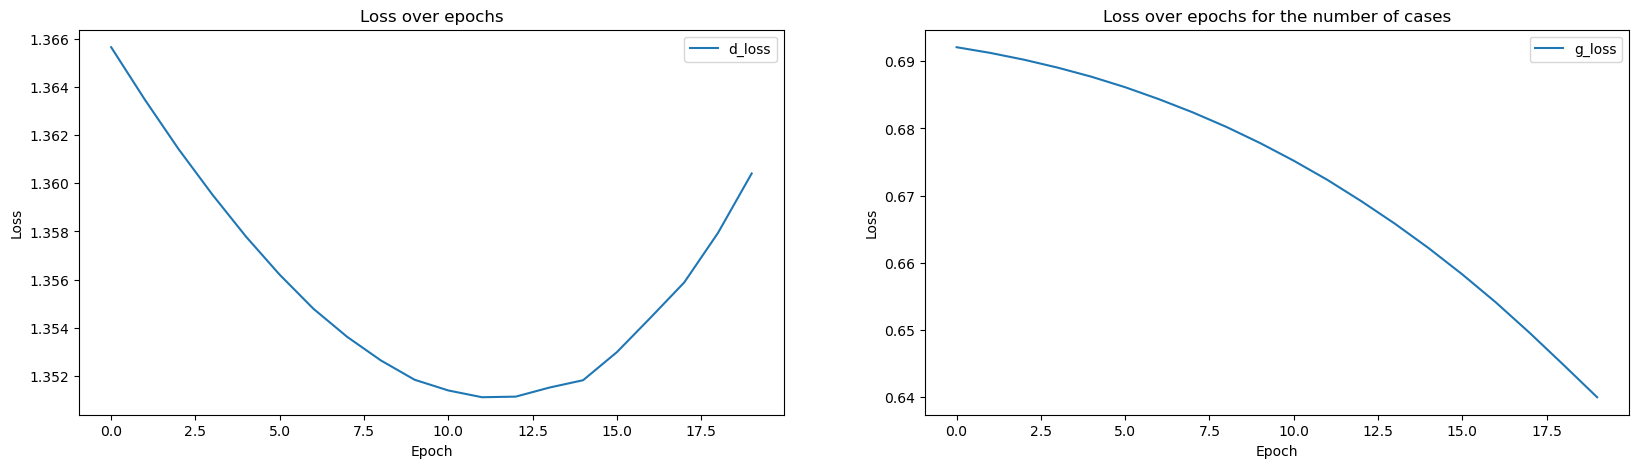

CPU times: total: 10min 34s
Wall time: 1min


In [49]:
%%time
## noiseSet = True  数据AN
## noiseSet = False 随机噪声数据
gan = ganData(61, 60, russia_df.copy(), 
              "Russia", noiseSet = True, 
              colName = "fatality_trend", iter_epoch=20) #confirmed_trend   fatality_trend

In [ ]:
gdata = gan.predict(1000)
np.save('ganDataNew/2stand_russia_del30_fatality_noise_1000',gdata )  #confirmed  fatality
gdata.shape

In [984]:
global_df = deal_global_df(population_, all_df, "World", "global")         ####
us_df     = deal_country_data(population_, all_df, "United States", "US")  ####
italy_df  = deal_country_data(population_, all_df, "Italy", "Italy")    ####
france_df = deal_country_data(population_, all_df, "France", "France")  ####
japan_df  = deal_country_data(population_, all_df, "Japan", "Japan")    ####

china_df   = deal_country_data(population_, all_df, "China", "China")
spain_df   = deal_country_data(population_, all_df, "Spain", "Spain")
uk_df      = deal_country_data(population_, all_df, "United Kingdom", "United Kingdom")
germany_df = deal_country_data(population_, all_df, "Germany", "Germany")
koread_df = deal_country_data(population_, all_df, "South Korea", "South Korea")

canada_df = deal_country_data(population_, all_df, "Canada", "Canada")
india_df = deal_country_data(population_, all_df, "India", "India")
russia_df = deal_country_data(population_, all_df, "Russia", "Russia")

global_df_ = addCsvDelNa(global_df)
us_df_     = addCsvDelNa(us_df)

italy_df_  = addCsvDelNa(italy_df)
# france_df_ = addCsvDelNa(france_df)
# japan_df_  = addCsvDelNa(japan_df)

# italy_df_  = addCsvRepNa(italy_df)
france_df_ = addCsvRepNa(france_df)
japan_df_  = addCsvRepNa(japan_df)

# china_df_   = addCsvRepNa(china_df)
# spain_df_   = addCsvRepNa(spain_df)
# uk_df_      = addCsvRepNa(uk_df)
# germany_df_ = addCsvRepNa(germany_df)

china_df_   = addCsvDelNa(china_df)
spain_df_   = addCsvDelNa(spain_df)
uk_df_      = addCsvDelNa(uk_df)
germany_df_ = addCsvDelNa(germany_df)



In [ ]:
# stand_global_+_del80_confirmed_noise_61_1000  SIR作为噪音数据 生成数据
# stand_global_+_del80_confirmed_SJ_noise_61_1000  随机噪声作为噪音数据 生成数据
